# Practical 1 - Understanding the Data

In [33]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

# Import our modules
from src.data_loader import download_dataset, MovieLensDataset
from src.data_structures import RatingMatrix
from src.visualization import (
    plot_rating_distribution,
    plot_distribution,
    plot_power_law,
    plot_zipf_rank,
    create_data_exploration_plots
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Download and Load the Dataset

In [34]:
# Download the dataset (only downloads if not already present)
data_path = download_dataset(dataset_name="ml-latest-small", data_dir="../data")

Dataset already exists at ..\data\ml-latest-small


In [35]:
# Load the dataset using our OOP wrapper
dataset = MovieLensDataset(data_path)

# Display summary
print(dataset.summary())

Loading ratings from ..\data\ml-latest-small\ratings.csv...
Loaded 100,836 ratings
MovieLens Dataset Summary
Users:              610
Items:            9,724
Ratings:        100,836
Sparsity:      98.3000%
Mean:             3.502



In [36]:
# Preview the ratings data
dataset.ratings.head(10)

,userId,movieId,rating,timestamp,user_idx,item_idx
0,1,1,4.0,964982703,0,0
1,1,3,4.0,964981247,0,2
2,1,6,4.0,964982224,0,5
3,1,47,5.0,964983815,0,43
4,1,50,5.0,964982931,0,46
5,1,70,3.0,964982400,0,62
6,1,101,5.0,964980868,0,89
7,1,110,4.0,964982176,0,97
8,1,151,5.0,964984041,0,124
9,1,157,5.0,964984100,0,130


In [37]:
# Preview the movies data
dataset.movies.head(10)

Loading movies from ..\data\ml-latest-small\movies.csv...
Loaded 9,742 movies


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


## 2. Build Data Structures

Build CSR-like indices for efficient access by user and by item. This structure is crucial for ALS-style alternating updates in later practicals.

In [38]:
# Get rating arrays
user_ids, item_ids, ratings = dataset.get_arrays()

# Build the rating matrix with dual indexing
rating_matrix = RatingMatrix(
    user_ids=user_ids,
    item_ids=item_ids,
    ratings=ratings,
    n_users=dataset.n_users,
    n_items=dataset.n_items
)

print(rating_matrix)

RatingMatrix(users=610, items=9,724, ratings=100,836, sparsity=98.3000%)


In [39]:
# Example: Get all ratings by user 0
items, user_ratings = rating_matrix.get_user_ratings(0)
print(f"User 0 has rated {len(items)} items")
print(f"First 5 items: {items[:5]}")
print(f"Corresponding ratings: {user_ratings[:5]}")

User 0 has rated 232 items
First 5 items: [   0 1733 1742 1754 1767]
Corresponding ratings: [4. 5. 2. 5. 4.]


In [40]:
# Example: Get all ratings for item 0
users, item_ratings = rating_matrix.get_item_ratings(0)
print(f"Item 0 has {len(users)} ratings")
print(f"First 5 users: {users[:5]}")
print(f"Their ratings: {item_ratings[:5]}")

Item 0 has 215 ratings
First 5 users: [  0 516 212 513 213]
Their ratings: [4.  4.  3.5 4.  3. ]


## 3. Rating Distribution Analysis

FileNotFoundError: [Errno 2] No such file or directory: '../figures/practical_1_rating_distribution.pdf'

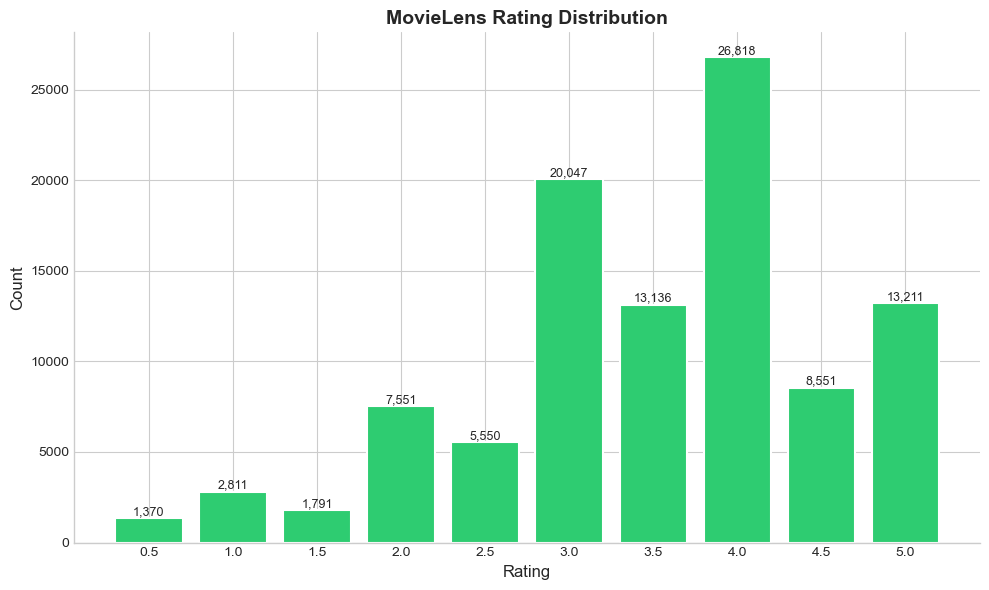

In [41]:
# Plot rating distribution
fig = plot_rating_distribution(
    ratings,
    title="MovieLens Rating Distribution"
)
plt.savefig('../figures/practical_1_rating_distribution.pdf', format='pdf')
plt.show()

In [ ]:
# Rating statistics
print(f"Rating Statistics:")
print(f"  Mean:   {np.mean(ratings):.3f}")
print(f"  Median: {np.median(ratings):.3f}")
print(f"  Std:    {np.std(ratings):.3f}")
print(f"  Min:    {np.min(ratings):.1f}")
print(f"  Max:    {np.max(ratings):.1f}")

Rating Statistics:
  Mean:   3.502
  Median: 3.500
  Std:    1.043
  Min:    0.5
  Max:    5.0


## 4. User Activity Distribution

Most users rate few items, while a small number of "power users" rate many items. This is characteristic of scale-free networks.

In [ ]:
# Get user activity counts
user_counts = dataset.get_user_counts()

print(f"User Activity Statistics:")
print(f"  Mean ratings per user:   {np.mean(user_counts):.1f}")
print(f"  Median ratings per user: {np.median(user_counts):.1f}")
print(f"  Most active user:        {np.max(user_counts):,} ratings")
print(f"  Least active user:       {np.min(user_counts)} ratings")

User Activity Statistics:
  Mean ratings per user:   165.3
  Median ratings per user: 70.5
  Most active user:        2,698 ratings
  Least active user:       20 ratings


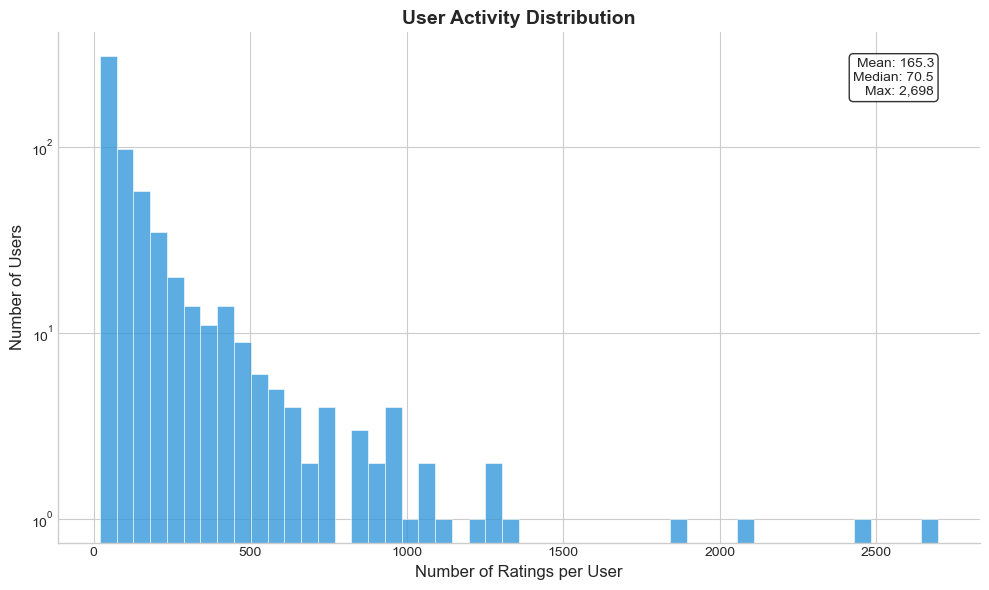

In [ ]:
# Plot user activity distribution (histogram)
fig = plot_distribution(
    user_counts,
    title="User Activity Distribution",
    xlabel="Number of Ratings per User",
    ylabel="Number of Users",
    log_scale=True
)
plt.savefig('../figures/practical_1_user_activity_distribution.pdf', format='pdf')
plt.show()

## 5. Item Popularity Distribution

Item popularity follows a power law (Zipf's law). A few "blockbuster" items receive most ratings, while the "long tail" of items receives very few.

In [ ]:
# Get item popularity counts
item_counts = dataset.get_item_counts()

print(f"Item Popularity Statistics:")
print(f"  Mean ratings per item:    {np.mean(item_counts):.1f}")
print(f"  Median ratings per item:  {np.median(item_counts):.1f}")
print(f"  Most popular item:        {np.max(item_counts):,} ratings")
print(f"  Least popular item:       {np.min(item_counts)} ratings")

Item Popularity Statistics:
  Mean ratings per item:    10.4
  Median ratings per item:  3.0
  Most popular item:        329 ratings
  Least popular item:       1 ratings


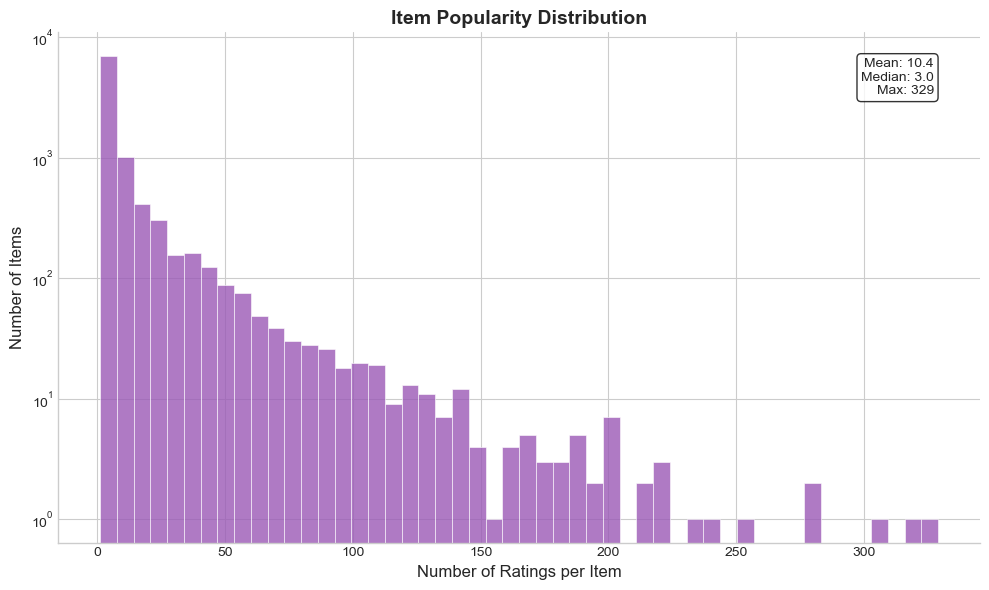

In [ ]:
# Plot item popularity distribution
fig = plot_distribution(
    item_counts,
    title="Item Popularity Distribution",
    xlabel="Number of Ratings per Item",
    ylabel="Number of Items",
    log_scale=True,
    color="#9b59b6"
)
plt.savefig('../figures/practical_1_item_popularity_distribution.pdf', format='pdf')
plt.show()

## 6. Power Law Analysis

A power law distribution has the form: $p(k) \propto k^{-\gamma}$

On a log-log plot, this appears as a straight line with slope $-\gamma$.

c:\Users\ayman\Downloads\aims\Applied ML at Scale\project\notebooks\..\src\visualization.py:179: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
c:\Users\ayman\Downloads\aims\Applied ML at Scale\project\notebooks\..\src\visualization.py:179: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
C:\Users\ayman\AppData\Local\Temp\ipykernel_34788\3889579151.py:10: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.savefig('../figures/practical_1_user_power_law.pdf', format='pdf')
C:\Users\ayman\AppData\Local\Temp\ipykernel_34788\3889579151.py:10: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.savefig('../figures/practical_1_user_power_law.pdf', format='pdf')
C:\Users\ayman\AppData\Local\Temp\ipykernel_34788\3889579151.py:10: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.savefig('../figures/practical_1_user_power_law.pdf'

Estimated power law exponent γ for users: 0.54


c:\Users\ayman\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ayman\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


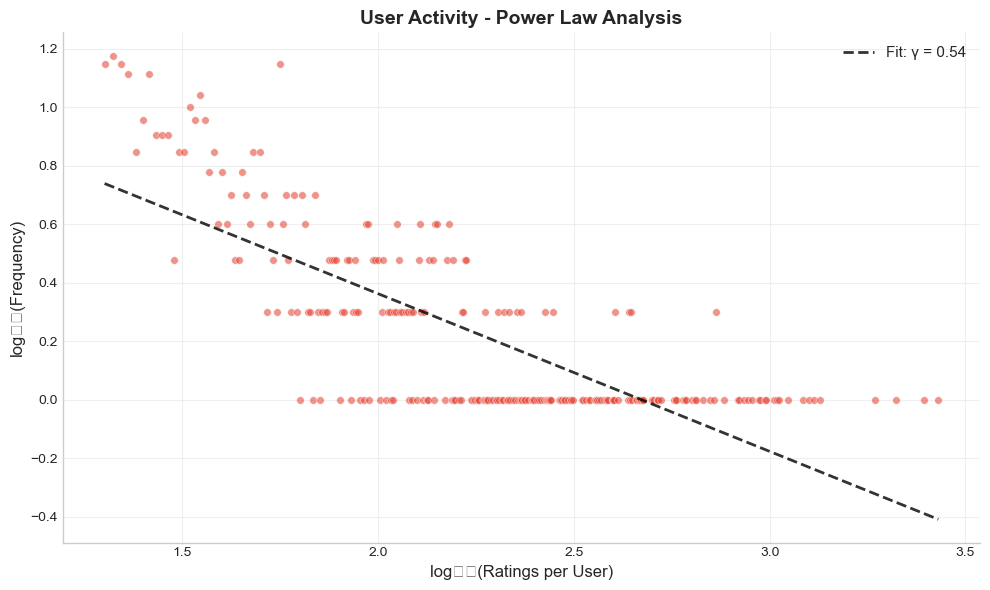

In [ ]:
# Power law analysis for user activity
fig, gamma = plot_power_law(
    user_counts,
    title="User Activity - Power Law Analysis",
    xlabel="log₁₀(Ratings per User)",
    ylabel="log₁₀(Frequency)"
)
if gamma:
    print(f"Estimated power law exponent γ for users: {gamma:.2f}")
plt.savefig('../figures/practical_1_user_power_law.pdf', format='pdf')
plt.show()

c:\Users\ayman\Downloads\aims\Applied ML at Scale\project\notebooks\..\src\visualization.py:179: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
c:\Users\ayman\Downloads\aims\Applied ML at Scale\project\notebooks\..\src\visualization.py:179: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
C:\Users\ayman\AppData\Local\Temp\ipykernel_34788\1239090556.py:11: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.savefig('../figures/practical_1_item_power_law.pdf', format='pdf')
C:\Users\ayman\AppData\Local\Temp\ipykernel_34788\1239090556.py:11: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.savefig('../figures/practical_1_item_power_law.pdf', format='pdf')
C:\Users\ayman\AppData\Local\Temp\ipykernel_34788\1239090556.py:11: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.savefig('../figures/practical_1_item_power_law.pdf'

Estimated power law exponent γ for items: 1.65


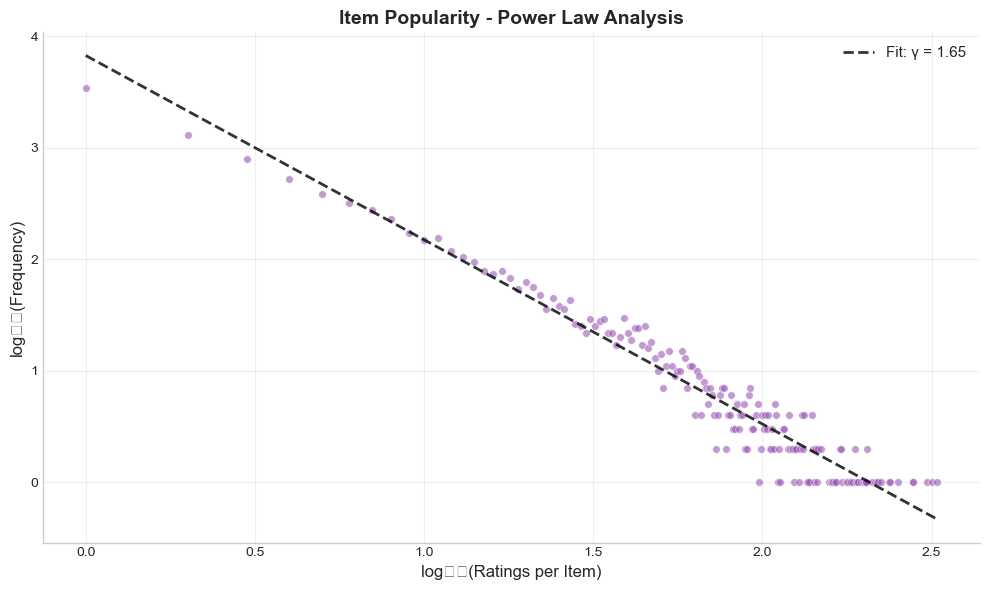

In [ ]:
# Power law analysis for item popularity
fig, gamma = plot_power_law(
    item_counts,
    title="Item Popularity - Power Law Analysis",
    xlabel="log₁₀(Ratings per Item)",
    ylabel="log₁₀(Frequency)",
    color="#9b59b6"
)
if gamma:
    print(f"Estimated power law exponent γ for items: {gamma:.2f}")
plt.savefig('../figures/practical_1_item_power_law.pdf', format='pdf')
plt.show()

## 7. Zipf's Law Analysis

Zipf's law states: $\text{frequency} \propto \frac{1}{\text{rank}}$

We sort items by popularity and plot rank vs. frequency.

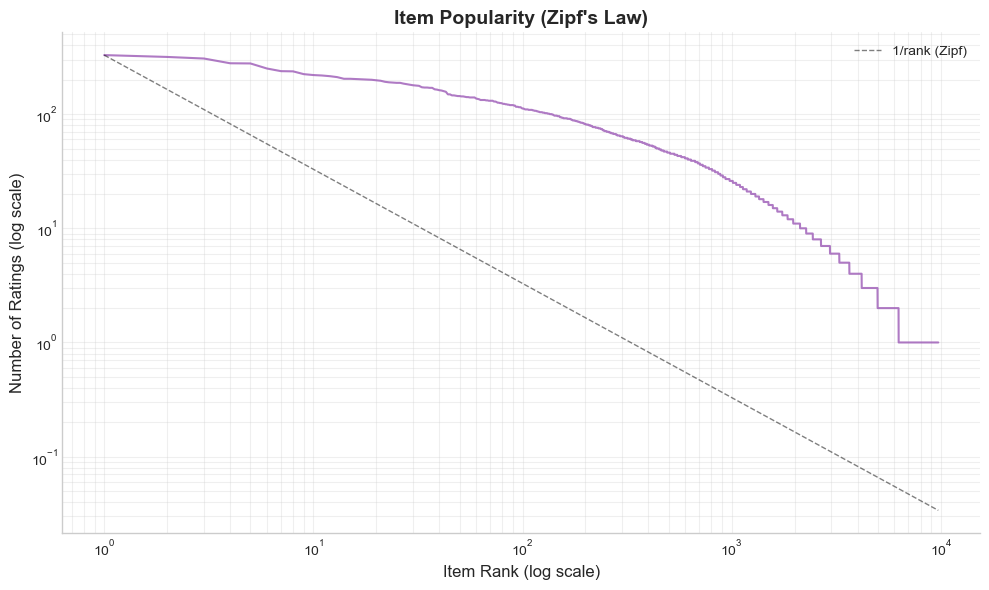

In [ ]:
# Zipf plot for item popularity
fig = plot_zipf_rank(
    item_counts,
    title="Item Popularity (Zipf's Law)",
    xlabel="Item Rank (log scale)",
    ylabel="Number of Ratings (log scale)"
)
plt.show()

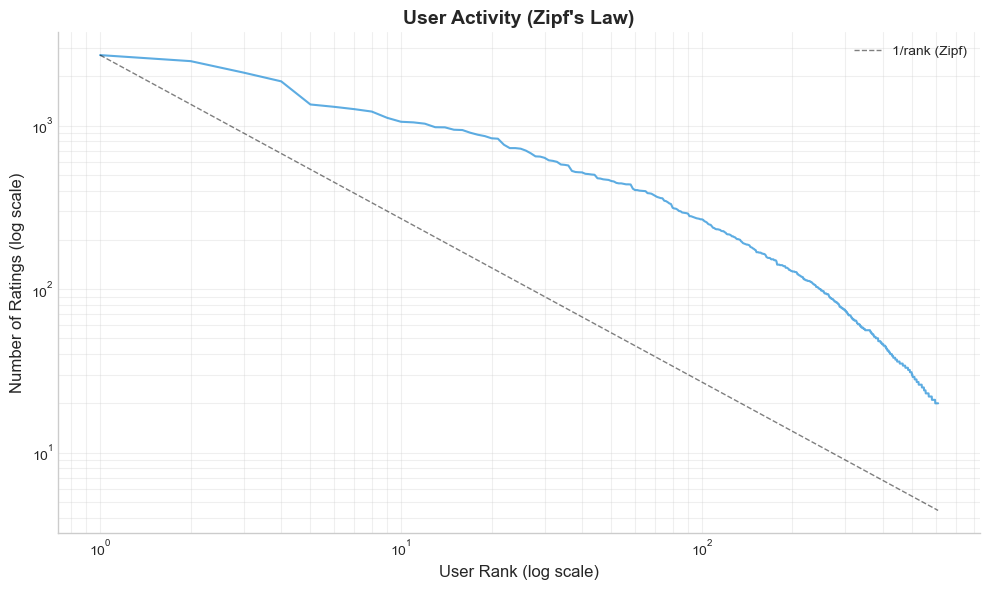

In [ ]:
# Zipf plot for user activity
fig = plot_zipf_rank(
    user_counts,
    title="User Activity (Zipf's Law)",
    xlabel="User Rank (log scale)",
    ylabel="Number of Ratings (log scale)",
    color="#3498db"
)
plt.show()

## 8. Comprehensive Visualization

A single 2x2 figure summarizing all key data characteristics.

c:\Users\ayman\Downloads\aims\Applied ML at Scale\project\notebooks\..\src\visualization.py:308: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
c:\Users\ayman\Downloads\aims\Applied ML at Scale\project\notebooks\..\src\visualization.py:308: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
C:\Users\ayman\AppData\Local\Temp\ipykernel_34788\4178186347.py:8: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.savefig('../figures/practical_1_comprehensive_overview.pdf', format='pdf')
C:\Users\ayman\AppData\Local\Temp\ipykernel_34788\4178186347.py:8: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.savefig('../figures/practical_1_comprehensive_overview.pdf', format='pdf')
C:\Users\ayman\AppData\Local\Temp\ipykernel_34788\4178186347.py:8: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.savefig('../figures/practical_1_compre

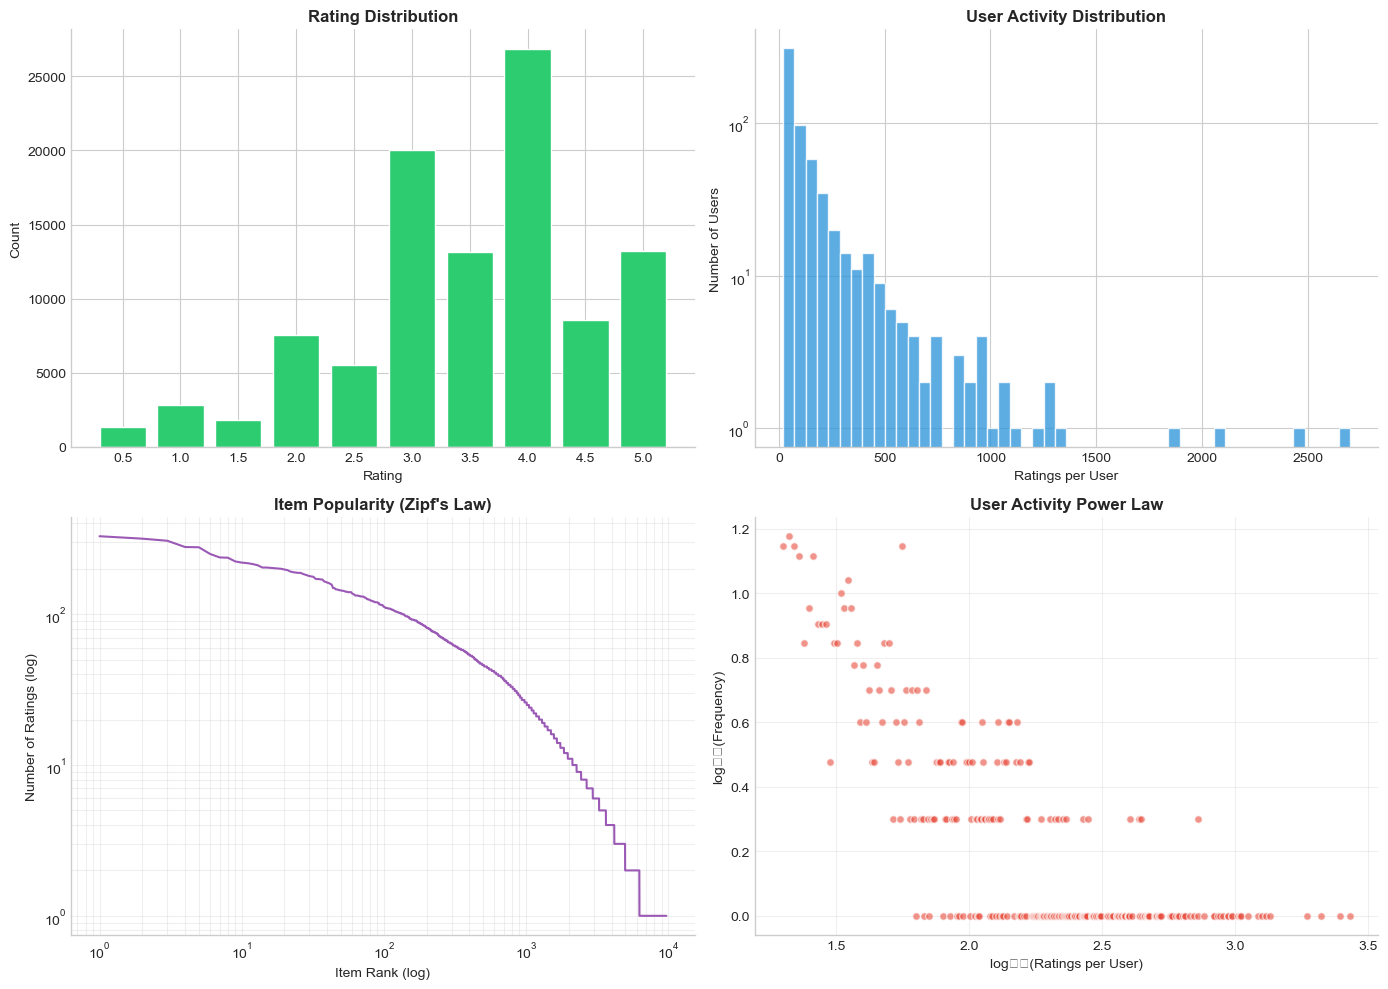

In [ ]:
# Create comprehensive plot
fig = create_data_exploration_plots(
    ratings=ratings,
    user_counts=user_counts,
    item_counts=item_counts,
    figsize=(14, 10)
)
plt.savefig('../figures/practical_1_comprehensive_overview.pdf', format='pdf')
plt.show()